In [ ]:
#Import libraries
import pandas as pd
import numpy as np
import ast
import json
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#Load both datasets
raw_df = pd.read_csv(
    "/content/CTS_CRM_15000_NLP_Preprocessed.csv"
)

benchmark_df = pd.read_csv(
    "/content/02_output_15000.csv"
)

print("Raw:", raw_df.shape)
print("Output:", benchmark_df.shape)

Raw: (15000, 23)
Output: (15000, 10)


In [ ]:
print(
    raw_df[
        ["interaction_id", "crm_note_id"]
    ].head()
)

print(
    benchmark_df[
        ["interaction_id", "crm_note_id"]
    ].head()
)

  interaction_id crm_note_id
0      INT000001   CRM000001
1      INT000002   CRM000002
2      INT000003   CRM000003
3      INT000004   CRM000004
4      INT000005   CRM000005
  interaction_id crm_note_id
0      INT000001   CRM000001
1      INT000002   CRM000002
2      INT000003   CRM000003
3      INT000004   CRM000004
4      INT000005   CRM000005


In [ ]:
print(
    "Raw duplicate IDs:",
    raw_df["interaction_id"].duplicated().sum()
)

print(
    "Benchmark duplicate IDs:",
    benchmark_df["interaction_id"].duplicated().sum()
)

Raw duplicate IDs: 0
Benchmark duplicate IDs: 0


In [ ]:
#Merge the datasets
dashboard_df = raw_df.merge(
    benchmark_df,
    on=["interaction_id", "crm_note_id"],
    how="inner"
)

In [ ]:
print("Merged shape:", dashboard_df.shape)

Merged shape: (15000, 31)


In [ ]:
assert len(dashboard_df) == len(raw_df)

In [ ]:
#Inspect the important columns
print(
    dashboard_df[
        [
            "interaction_date",
            "brand_name",
            "reference_sentiment",
            "reference_topics",
            "reference_primary_objection"
        ]
    ].head()
)

  interaction_date brand_name reference_sentiment  \
0       2026-01-01  Arthrelis               Mixed   
1       2026-02-28  Arthrelis               Mixed   
2       2026-03-04  Arthrelis               Mixed   
3       2026-03-12  Arthrelis               Mixed   
4       2026-03-18   Rheumora            Negative   

                            reference_topics  reference_primary_objection  
0               Tolerability|Safety|Efficacy  Side Effects / Tolerability  
1                     Tolerability|Adherence            Adherence Concern  
2  Adherence|Efficacy|Access / Reimbursement          Prior Authorization  
3                              Efficacy|Cost      High Out-of-Pocket Cost  
4                     Access / Reimbursement          Prior Authorization  


In [ ]:
#Convert date properly
dashboard_df["interaction_date"] = pd.to_datetime(
    dashboard_df["interaction_date"],
    errors="coerce"
)

In [ ]:
#create month
dashboard_df["month"] = (
    dashboard_df["interaction_date"]
    .dt.to_period("M")
    .astype(str)
)

In [ ]:
#inspect the topic and objection format
print(
    dashboard_df["reference_topics"]
    .head(10)
    .tolist()
)

print(
    dashboard_df["reference_primary_objection"]
    .head(10)
    .tolist()
)

['Tolerability|Safety|Efficacy', 'Tolerability|Adherence', 'Adherence|Efficacy|Access / Reimbursement', 'Efficacy|Cost', 'Access / Reimbursement', 'Access|Clinical Evidence|Access / Reimbursement', 'Ease of Use|Clinical Evidence', 'Safety', 'Access|Efficacy|Access / Reimbursement', 'Dosing / Administration']
['Side Effects / Tolerability', 'Adherence Concern', 'Prior Authorization', 'High Out-of-Pocket Cost', 'Prior Authorization', 'Clinical Evidence Gap', 'Clinical Evidence Gap', 'Safety Concern', 'No Objection', 'Dosing Complexity']


In [ ]:
#Prepare topics
def parse_list(value):
    try:
        return ast.literal_eval(value)
    except:
        return [str(value)]


dashboard_df["topic_list"] = (
    dashboard_df["reference_topics"]
    .apply(parse_list)
)

In [ ]:
topic_df = dashboard_df.explode(
    "topic_list"
).copy()

topic_df["topic"] = (
    topic_df["topic_list"]
    .astype(str)
    .str.strip()
)

In [ ]:
#CHART 1: HCP objections by brand
objection_brand = pd.crosstab(
    dashboard_df["brand_name"],
    dashboard_df["reference_primary_objection"]
)

In [ ]:
print(objection_brand)

reference_primary_objection  Adherence Concern  Clinical Evidence Gap  \
brand_name                                                              
Aerolyn                                     26                     11   
Alleriva                                    16                     18   
Arthrelis                                   25                     22   
Brevanta                                    28                     28   
Cardeza                                     37                     41   
Celunex                                     25                     17   
Clearvanta                                  29                     36   
Dermalune                                   38                     30   
Gastrel                                     25                     30   
Glycetra                                    55                     42   
Gutavex                                     14                     23   
Hepalune                                    12     

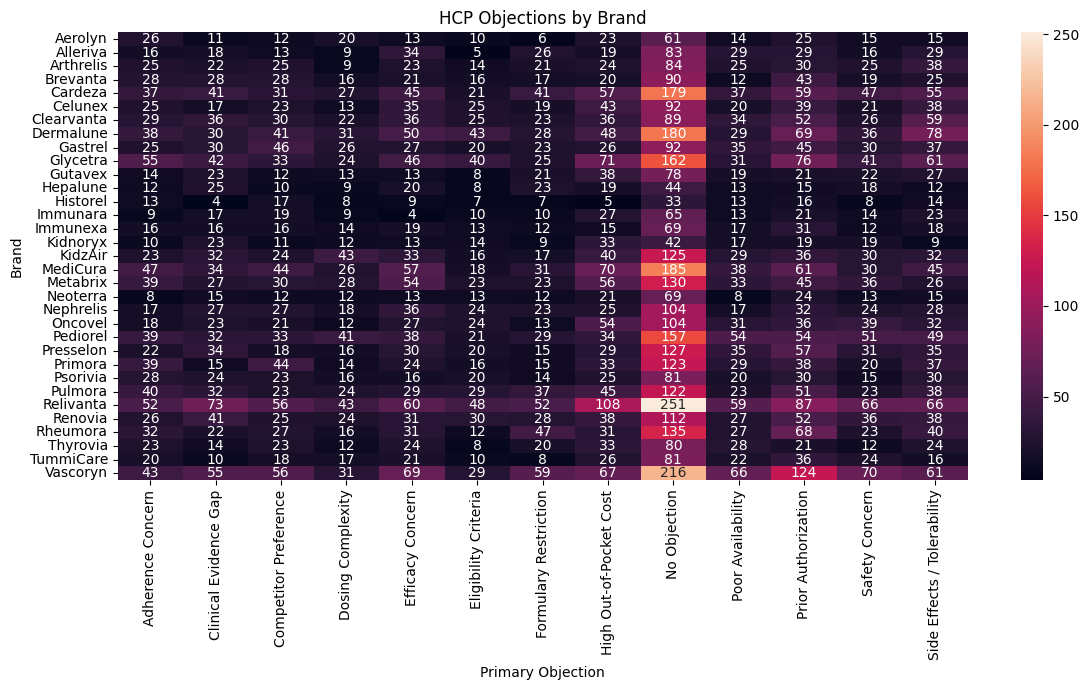

In [ ]:
plt.figure(figsize=(12, 7))

sns.heatmap(
    objection_brand,
    annot=True,
    fmt="d"
)

plt.title(
    "HCP Objections by Brand"
)

plt.xlabel("Primary Objection")
plt.ylabel("Brand")

plt.tight_layout()
plt.show()

Business meaning

This answers:

Which objections are particularly prominent for each brand?

In [ ]:
#CHART 2: Topic trends by month
topic_month = pd.crosstab(
    topic_df["month"],
    topic_df["topic"]
)

In [ ]:
topic_month.plot(
    figsize=(14, 7),
    marker="o"
)

plt.title(
    "Topic Trends Over Time"
)

plt.xlabel("Month")
plt.ylabel("Number of HCP Interactions")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Business meaning

You can identify:

Reimbursement ↑
Safety ↑
Efficacy ↓

In [ ]:
#CHART 3: Negative sentiment by brand
dashboard_df["is_negative"] = (
    dashboard_df["reference_sentiment"]
    .str.lower()
    .eq("negative")
)

In [ ]:
negative_brand = (
    dashboard_df
    .groupby("brand_name")["is_negative"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

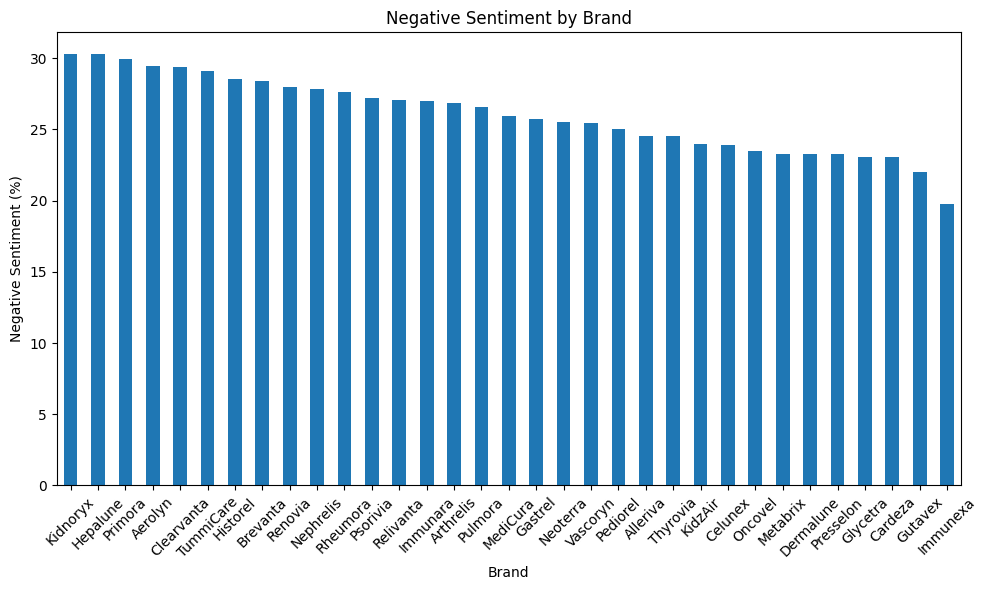

In [ ]:
plt.figure(figsize=(10, 6))

negative_brand.plot(
    kind="bar"
)

plt.title(
    "Negative Sentiment by Brand"
)

plt.xlabel("Brand")
plt.ylabel("Negative Sentiment (%)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Business meaning

You can identify:

Negative sentiment by different brands


In [ ]:
#CHART 4: Topics driving negative sentiment
# ---------------------------------------------------------
# NEGATIVE SENTIMENT BY TOPIC
# ---------------------------------------------------------

topic_df = dashboard_df.copy()

# Split pipe-separated topics
topic_df["topic"] = (
    topic_df["reference_topics"]
    .astype(str)
    .str.split("|")
)

# One topic per row
topic_df = topic_df.explode("topic")

# Clean topic names
topic_df["topic"] = (
    topic_df["topic"]
    .astype(str)
    .str.strip()
)

# Remove empty / invalid topics
topic_df = topic_df[
    (topic_df["topic"] != "") &
    (topic_df["topic"].str.lower() != "nan")
].copy()

In [ ]:
#Calculate negative sentiment percentage
# Convert sentiment to lowercase for reliable comparison
topic_df["sentiment_clean"] = (
    topic_df["reference_sentiment"]
    .astype(str)
    .str.strip()
    .str.lower()
)

# Calculate negative sentiment percentage for each topic
topic_negative = (
    topic_df
    .groupby("topic")["sentiment_clean"]
    .apply(
        lambda x: (
            x.eq("negative").mean() * 100
        )
    )
)

# Sort from highest to lowest
topic_negative = topic_negative.sort_values(
    ascending=False
)

In [ ]:
top_negative_topics = (
    topic_negative
    .head(10)
    .sort_values(ascending=True)
)

In [ ]:
print(top_negative_topics)

topic
Cost                       27.287762
Access / Formulary         27.674624
Dosing / Administration    27.821522
Patient Selection          27.886497
Adherence                  28.116343
Availability               28.249818
Tolerability               28.319088
Competitor                 29.088278
Access / Reimbursement     29.168646
Safety                     31.773585
Name: sentiment_clean, dtype: float64


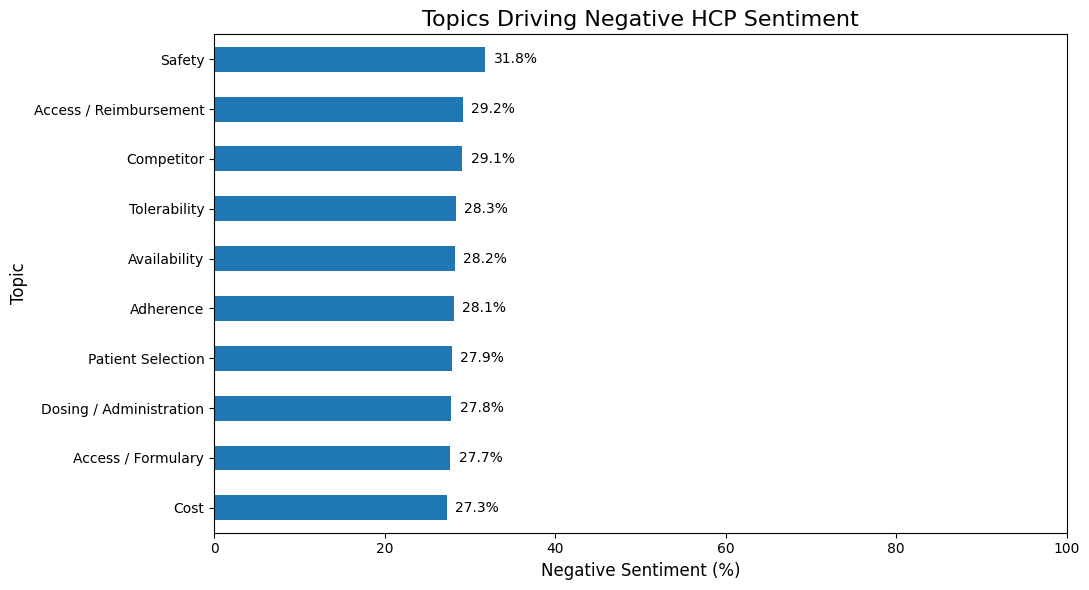

In [ ]:
plt.figure(figsize=(11, 6))

ax = top_negative_topics.plot(
    kind="barh"
)

plt.title(
    "Topics Driving Negative HCP Sentiment",
    fontsize=16
)

plt.xlabel(
    "Negative Sentiment (%)",
    fontsize=12
)

plt.ylabel(
    "Topic",
    fontsize=12
)

plt.xlim(0, 100)

# Add percentage labels
for i, value in enumerate(top_negative_topics):
    ax.text(
        value + 1,
        i,
        f"{value:.1f}%",
        va="center"
    )

plt.tight_layout()
plt.show()

This gives you a direct answer to:

Which topics have the strongest association with negative HCP sentiment?

In [ ]:
#CHART 5: What are HCPs most positive about?
topic_df = dashboard_df.copy()

topic_df["topic"] = (
    topic_df["reference_topics"]
    .astype(str)
    .str.split("|")
)

topic_df = topic_df.explode("topic")

topic_df["topic"] = (
    topic_df["topic"]
    .str.strip()
)

In [ ]:
topic_positive = (
    topic_df
    .groupby("topic")["reference_sentiment"]
    .apply(
        lambda x: (
            x.astype(str)
             .str.strip()
             .str.lower()
             .eq("positive")
             .mean() * 100
        )
    )
)

In [ ]:
top_positive_topics = (
    topic_positive
    .sort_values(ascending=False)
    .head(10)
)

In [ ]:
print(top_positive_topics)

topic
Ease of Use               31.637717
Patient Experience        31.471471
Dosing                    31.186686
Access                    30.362390
Efficacy                  22.675848
Clinical Evidence         19.577554
Access / Reimbursement     4.560570
Access / Formulary         4.509284
Tolerability               4.501425
Availability               4.357298
Name: reference_sentiment, dtype: float64


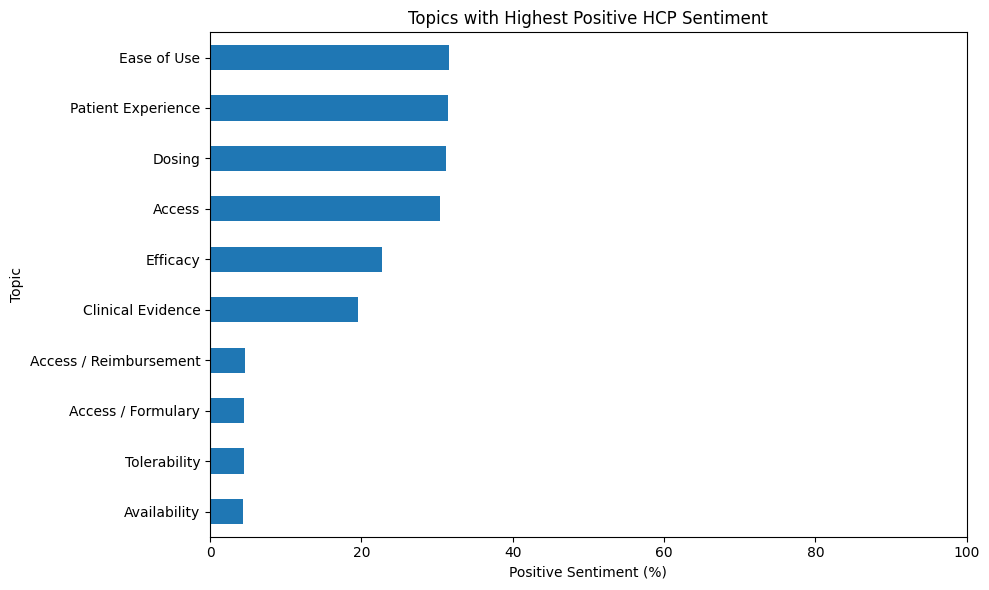

In [ ]:
plt.figure(figsize=(10, 6))

top_positive_topics.sort_values().plot(
    kind="barh"
)

plt.title(
    "Topics with Highest Positive HCP Sentiment"
)

plt.xlabel("Positive Sentiment (%)")
plt.ylabel("Topic")

plt.xlim(0, 100)

plt.tight_layout()
plt.show()

In [ ]:
#CHART 6: Emerging issues
#Are there emerging issues that were previously uncommon?
max_month = topic_df["month"].max()

recent_months = sorted(
    topic_df["month"].unique()
)[-3:]

previous_months = sorted(
    topic_df["month"].unique()
)[-6:-3]

In [ ]:
recent = topic_df[
    topic_df["month"].isin(recent_months)
]

previous = topic_df[
    topic_df["month"].isin(previous_months)
]

In [ ]:
recent_counts = (
    recent["topic"]
    .value_counts()
)

previous_counts = (
    previous["topic"]
    .value_counts()
)

In [ ]:
emerging = pd.DataFrame({
    "recent": recent_counts,
    "previous": previous_counts
}).fillna(0)

In [ ]:
#Calculate growth
emerging["growth_pct"] = np.where(
    emerging["previous"] > 0,
    (
        (emerging["recent"] - emerging["previous"])
        / emerging["previous"]
    ) * 100,
    np.nan
)

In [ ]:
print(
    emerging.sort_values(
        "growth_pct",
        ascending=False
    ).head(10)
)

                         recent  previous  growth_pct
topic                                                
Competitor                  590       533   10.694184
Adherence                   608       565    7.610619
Cost                        729       701    3.994294
Availability                567       546    3.846154
Access / Reimbursement      849       824    3.033981
Clinical Evidence          1215      1240   -2.016129
Dosing / Administration     449       464   -3.232759
Access / Formulary          443       460   -3.695652
Patient Selection           400       418   -4.306220
Access                      378       396   -4.545455


Business interpretation

A topic is more interesting when it is:

Increasing rapidly
Previously relatively uncommon
Associated with negative sentiment